### Cleaning The Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('data/raw/Algerian_forest_fires_dataset_UPDATE.csv', header=1)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.0+ KB


In [37]:
# Data Cleaning
df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region


In [49]:
### Dropping the null row
df.drop(123, inplace=True)

In [53]:
### Resetting the Indexex
df=df.reset_index(drop=True)

In [ ]:
### Checking are these all numeric or not
df[~df['day'].str.isnumeric()]

In [36]:
### Findiny the mode for NAN class
df['Classes  ']=df['Classes  '].fillna(df['Classes  '].mode()[0])

In [ ]:
#### Creating a new Feature for the Region 
df.loc[:122,"Region"]=0
df.loc[122:,"Region"]=1

In [39]:
df['Region']=df['Region'].astype(int)

In [51]:
df[['day','month','year']]=df[['day','month','year']].astype(int)

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 245 entries, 0 to 245
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          245 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      245 non-null    object
 14  Region       245 non-null    int64 
dtypes: int64(1), object(14)
memory usage: 30.6+ KB


In [54]:
df.head()
df['Rain ']

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [74]:
df[['Temperature',' RH',' Ws','Rain ','FFMC','DMC','DC','ISI','BUI']]=df[['Temperature',' RH',' Ws','Rain ','FFMC','DMC','DC','ISI','BUI']].astype(float)

In [ ]:
### Remove the Space from the DC Column
df['DC']=df['DC'].str.replace(" ","")

In [89]:
pd.to_numeric(df['FWI'],errors='coerce').isnull().sum()

np.int64(1)

In [90]:
df.loc[pd.to_numeric(df['FWI'], errors='coerce').isnull(), 'FWI']

165    fire   
Name: FWI, dtype: object

In [ ]:
# assigning NAN to 165 value
df.loc[165,'FWI']=np.nan

In [97]:
df.loc[160:170]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
160,9,7,2012,36.0,43.0,15.0,1.9,82.3,9.4,9.90,3.2,9.0,3.1,fire,1
161,10,7,2012,34.0,51.0,16.0,3.8,77.5,8.0,9.50,2.0,7.7,1.3,not fire,1
162,11,7,2012,34.0,56.0,15.0,2.9,74.8,7.1,9.50,1.6,6.8,0.8,not fire,1
163,12,7,2012,36.0,44.0,13.0,0.0,90.1,12.6,19.40,8.3,12.5,9.6,fire,1
164,13,7,2012,39.0,45.0,13.0,0.6,85.2,11.3,10.40,4.2,10.9,4.7,fire,1
165,14,7,2012,37.0,37.0,18.0,0.2,88.9,12.9,14.69,12.5,10.4,NaN,fire,1
166,15,7,2012,34.0,45.0,17.0,0.0,90.5,18.0,24.10,10.9,17.7,14.1,fire,1
167,16,7,2012,31.0,83.0,17.0,0.0,84.5,19.4,33.10,4.7,19.2,7.3,fire,1
168,17,7,2012,32.0,81.0,17.0,0.0,84.6,21.1,42.30,4.7,20.9,7.7,fire,1
169,18,7,2012,33.0,68.0,15.0,0.0,86.1,23.9,51.60,5.2,23.9,9.1,fire,1


In [ ]:
df['FWI']=df['FWI'].astype(float)

In [104]:
df['FWI']=df['FWI'].fillna(df['FWI'].mean())

In [106]:
df['FWI'].isnull().sum()

np.int64(0)

In [110]:
#### Removing the Features Names Spaces
df.columns=df.columns.str.strip()

In [111]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [112]:
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,244.000000,244.000000,244.0,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000
mean,15.754098,7.500000,2012.0,32.172131,61.938525,15.504098,0.760656,77.887705,14.673361,49.288484,4.774180,16.664754,7.035391,0.500000
std,8.825059,1.112961,0.0,3.633843,14.884200,2.810178,1.999406,14.337571,12.368039,47.619393,4.175318,14.204824,7.425242,0.501028
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.000000,14.000000,0.000000,72.075000,5.800000,13.275000,1.400000,6.000000,0.700000,0.000000
50%,16.000000,7.500000,2012.0,32.000000,63.000000,15.000000,0.000000,83.500000,11.300000,33.100000,3.500000,12.250000,4.450000,0.500000
75%,23.000000,8.000000,2012.0,35.000000,73.250000,17.000000,0.500000,88.300000,20.750000,68.150000,7.300000,22.525000,11.375000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


In [ ]:
df['Classes']=df['Classes'].str.strip()

In [132]:
#### Saving the CSV File
df.to_csv('data/raw/Algerian_forest_fires_dataset_Cleaned.csv',index=False)

### Exploratory Data Analysis & Feature Engineering

In [136]:
## Dropping DAy, Month and Year
df_copy=df.drop(['day','month','year'],axis=1)

In [139]:
df_copy['Classes']=np.where(df_copy['Classes']=='not fire',0,1)

In [142]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  244 non-null    float64
 1   RH           244 non-null    float64
 2   Ws           244 non-null    float64
 3   Rain         244 non-null    float64
 4   FFMC         244 non-null    float64
 5   DMC          244 non-null    float64
 6   DC           244 non-null    float64
 7   ISI          244 non-null    float64
 8   BUI          244 non-null    float64
 9   FWI          244 non-null    float64
 10  Classes      244 non-null    int64  
 11  Region       244 non-null    int64  
dtypes: float64(10), int64(2)
memory usage: 23.0 KB


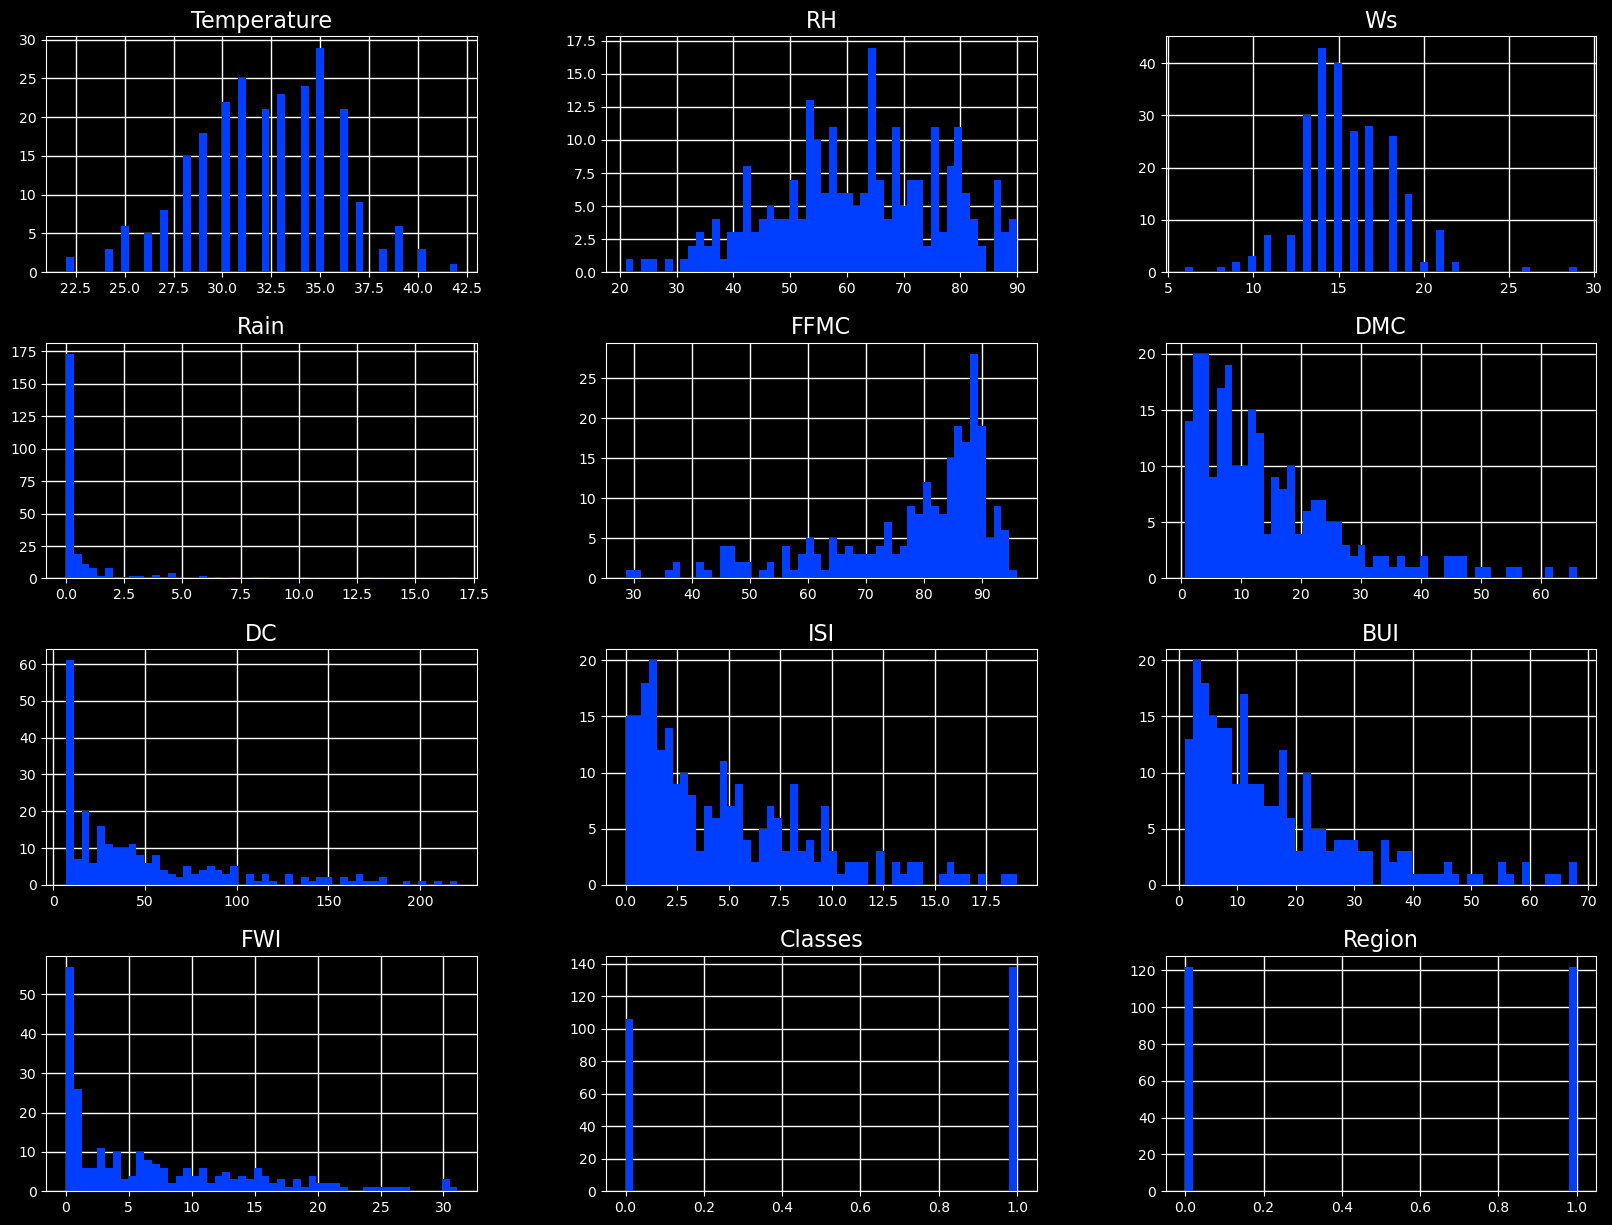

In [161]:
#### Visualization
plt.style.use('seaborn-v0_8-bright')
df_copy.hist(bins=50,figsize=(20,15))
plt.show()

In [163]:
perc=df_copy['Classes'].value_counts(normalize=True)*100

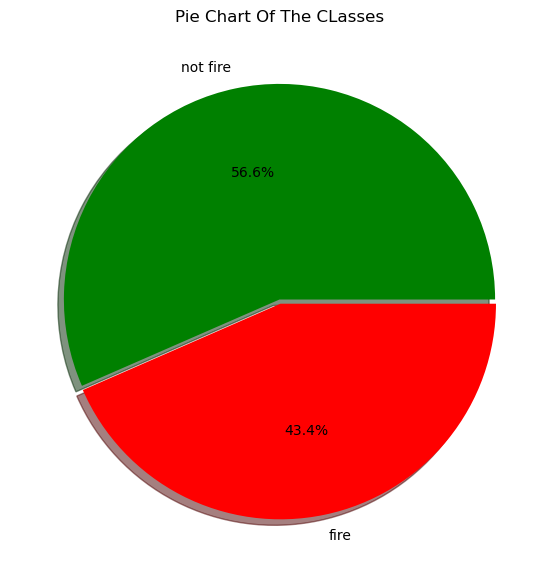

In [179]:
class_label=['not fire','fire']
plt.style.use('default')
plt.figure(figsize=(12,7))
plt.pie(perc,explode=(0,0.02),labels=class_label,autopct='%1.1f%%',colors=['Green','Red'],shadow=True)
plt.title('Pie Chart Of The CLasses')
plt.show()

In [180]:
### Correalation
df_copy.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.654443,-0.278132,-0.326786,0.677491,0.483105,0.370511,0.607551,0.455504,0.564599,0.518119,0.273496
RH,-0.654443,1.000000,0.236084,0.222968,-0.645658,-0.405133,-0.220344,-0.690637,-0.348587,-0.577577,-0.435023,-0.406424
Ws,-0.278132,0.236084,1.000000,0.170169,-0.163255,-0.001246,0.076253,0.015248,0.029756,0.032315,-0.066529,-0.176829
Rain,-0.326786,0.222968,0.170169,1.000000,-0.544045,-0.288548,-0.296808,-0.347105,-0.299171,-0.324369,-0.379449,-0.041080
FFMC,0.677491,-0.645658,-0.163255,-0.544045,1.000000,0.602391,0.503919,0.739730,0.589652,0.690289,0.770114,0.224680
DMC,0.483105,-0.405133,-0.001246,-0.288548,0.602391,1.000000,0.875362,0.674499,0.982073,0.875827,0.584188,0.191094
DC,0.370511,-0.220344,0.076253,-0.296808,0.503919,0.875362,1.000000,0.498926,0.941906,0.738714,0.507132,-0.081482
ISI,0.607551,-0.690637,0.015248,-0.347105,0.739730,0.674499,0.498926,1.000000,0.635891,0.916343,0.735511,0.268421
BUI,0.455504,-0.348587,0.029756,-0.299171,0.589652,0.982073,0.941906,0.635891,1.000000,0.857628,0.583882,0.087370
FWI,0.564599,-0.577577,0.032315,-0.324369,0.690289,0.875827,0.738714,0.916343,0.857628,1.000000,0.718079,0.196696


<Axes: >

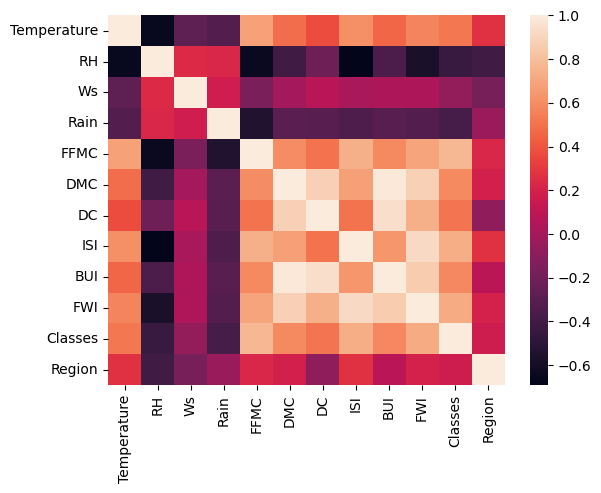

In [181]:
sns.heatmap(df_copy.corr())

Text(0.5, 1.0, 'Fire Analysis of Bejai Region')

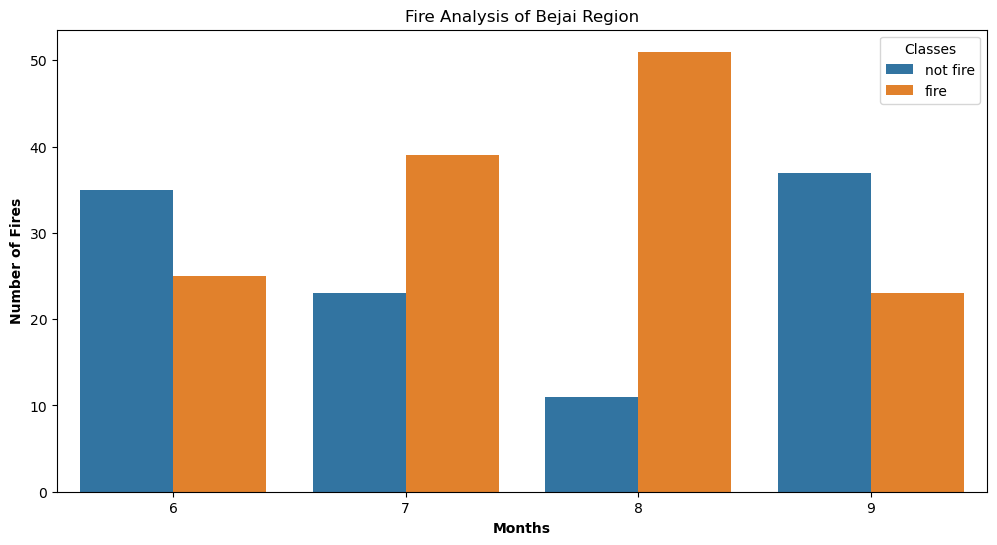

In [187]:
dftemp = df.loc[df['Region']==0]
plt.subplots(figsize=(12,6))
sns.countplot(x=df['month'],hue='Classes',data=df)
plt.ylabel('Number of Fires', weight='bold')
plt.xlabel('Months', weight='bold')
plt.title('Fire Analysis of Bejai Region')

Text(0.5, 1.0, 'Fire Analysis of Bejai Region')

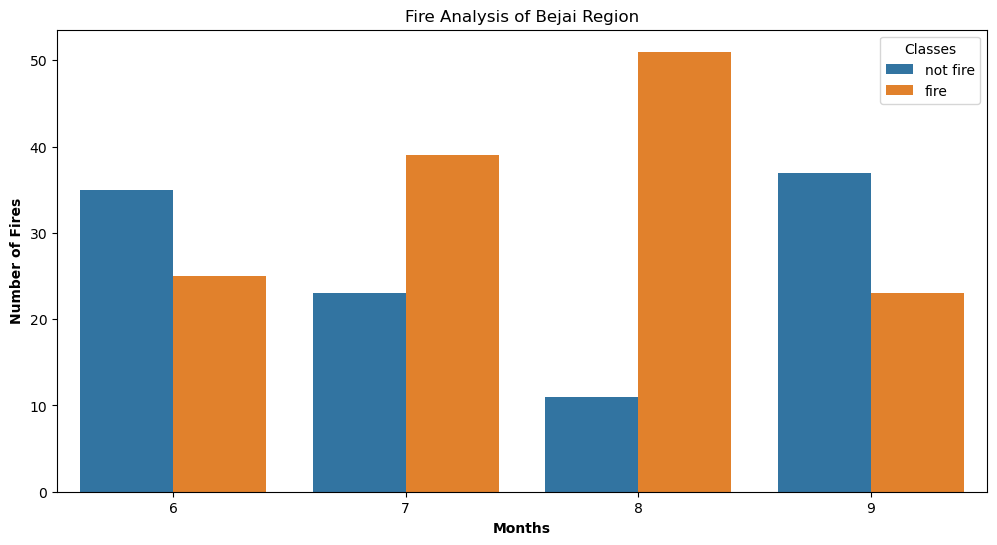

In [186]:
dftemp = df.loc[df['Region']==1]
plt.subplots(figsize=(12,6))
sns.countplot(x=df['month'],hue='Classes',data=df)
plt.ylabel('Number of Fires', weight='bold')
plt.xlabel('Months', weight='bold')
plt.title('Fire Analysis of Bejai Region')

## Model Training

In [189]:
df=pd.read_csv('data/raw/Algerian_forest_fires_dataset_Cleaned.csv')

In [222]:
### Independent & Dependent Features
X= df.drop('FWI',axis=1)
y=df['FWI']

In [196]:
df['Classes']=np.where(df['Classes']=='not fire',0,1)

In [199]:
df.drop(['day','month','year'],axis=1,inplace=True)

In [321]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [231]:
### Feature Selection based on the Corr
corr=X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.664492,-0.249312,-0.375047,0.703238,0.485379,0.374689,0.609525,0.458575,0.512818,0.256099
RH,-0.664492,1.000000,0.235766,0.262550,-0.637201,-0.398168,-0.215094,-0.694976,-0.344365,-0.429397,-0.397053
Ws,-0.249312,0.235766,1.000000,0.262759,-0.169489,-0.013533,0.073933,0.015384,0.022529,-0.078171,-0.229797
Rain,-0.375047,0.262550,0.262759,1.000000,-0.585018,-0.291338,-0.296119,-0.353219,-0.301347,-0.394262,-0.096985
FFMC,0.703238,-0.637201,-0.169489,-0.585018,1.000000,0.602278,0.508360,0.744270,0.592841,0.774398,0.237434
DMC,0.485379,-0.398168,-0.013533,-0.291338,0.602278,1.000000,0.877050,0.652894,0.981876,0.580530,0.197489
DC,0.374689,-0.215094,0.073933,-0.296119,0.508360,0.877050,1.000000,0.496586,0.941251,0.501292,-0.079207
ISI,0.609525,-0.694976,0.015384,-0.353219,0.744270,0.652894,0.496586,1.000000,0.624038,0.744568,0.267027
BUI,0.458575,-0.344365,0.022529,-0.301347,0.592841,0.981876,0.941251,0.624038,1.000000,0.583094,0.092548
Classes,0.512818,-0.429397,-0.078171,-0.394262,0.774398,0.580530,0.501292,0.744568,0.583094,1.000000,0.158763


In [323]:
X_train

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
115,29.0,65.0,19.0,0.6,68.3,5.5,15.2,1.5,5.8,0,0
181,36.0,56.0,16.0,0.0,88.9,23.8,57.1,8.2,23.8,1,1
225,31.0,72.0,14.0,0.0,84.2,8.3,25.2,3.8,9.1,1,1
68,32.0,60.0,18.0,0.3,77.1,11.3,47.0,2.2,14.1,0,0
104,25.0,86.0,21.0,4.6,40.9,1.3,7.5,0.1,1.8,0,0
...,...,...,...,...,...,...,...,...,...,...,...
106,24.0,82.0,15.0,0.4,44.9,0.9,7.3,0.2,1.4,0,0
14,28.0,80.0,17.0,3.1,49.4,3.0,7.4,0.4,3.0,0,0
92,25.0,76.0,17.0,7.2,46.0,1.3,7.5,0.2,1.8,0,0
179,33.0,57.0,16.0,0.0,87.5,15.7,37.6,6.7,15.7,1,1


Text(0.5, 1.0, 'Multi-Colinearity')

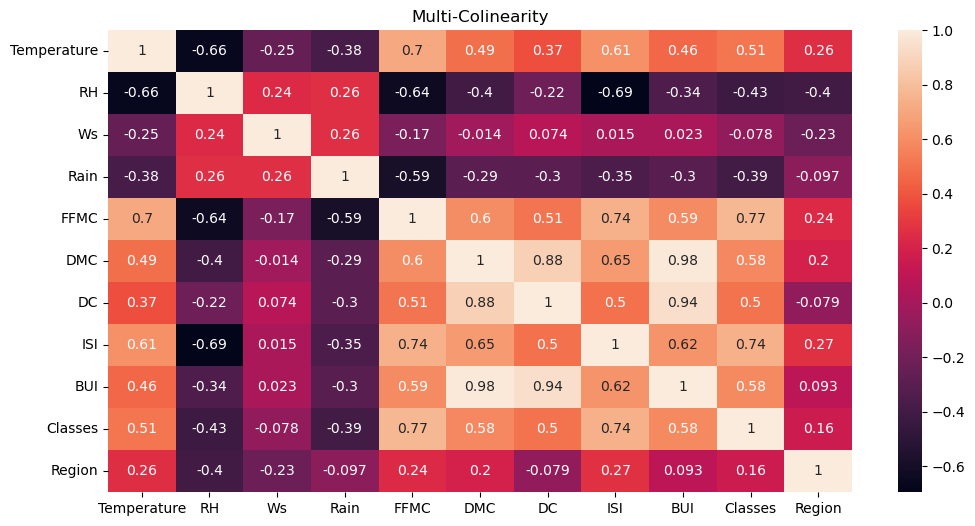

In [249]:
### Check For multi-Colinearity
plt.figure(figsize=(12,6))
corr=X_train.corr()
sns.heatmap(corr,annot=True)
plt.xticks(rotation=360)
plt.xticks(fontsize=10)
plt.title('Multi-Colinearity')

In [252]:
def correlation(dataset,threshold):
    col_corr=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]>threshold):
                colname=corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [256]:
corr_features=correlation(X_train,0.80)

In [324]:
### Drop Features with co-relation more than 0.80
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)

In [325]:
X_train.shape,X_test.shape

((183, 9), (61, 9))

In [326]:
X_train

,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,Classes,Region
115,29.0,65.0,19.0,0.6,68.3,5.5,1.5,0,0
181,36.0,56.0,16.0,0.0,88.9,23.8,8.2,1,1
225,31.0,72.0,14.0,0.0,84.2,8.3,3.8,1,1
68,32.0,60.0,18.0,0.3,77.1,11.3,2.2,0,0
104,25.0,86.0,21.0,4.6,40.9,1.3,0.1,0,0
...,...,...,...,...,...,...,...,...,...
106,24.0,82.0,15.0,0.4,44.9,0.9,0.2,0,0
14,28.0,80.0,17.0,3.1,49.4,3.0,0.4,0,0
92,25.0,76.0,17.0,7.2,46.0,1.3,0.2,0,0
179,33.0,57.0,16.0,0.0,87.5,15.7,6.7,1,1


In [327]:
X_test

,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,Classes,Region
24,31.0,64.0,15.0,0.0,86.7,14.2,5.7,1,0
6,33.0,54.0,13.0,0.0,88.2,9.9,6.4,1,0
153,33.0,48.0,16.0,0.0,87.6,7.9,6.8,1,1
211,35.0,53.0,17.0,0.5,80.2,20.7,2.7,1,1
198,40.0,41.0,10.0,0.1,92.0,22.6,9.5,1,1
...,...,...,...,...,...,...,...,...,...
172,36.0,29.0,18.0,0.0,93.9,39.6,18.5,1,1
242,24.0,54.0,18.0,0.1,79.7,4.3,1.7,0,1
152,28.0,58.0,18.0,2.2,63.7,3.2,1.2,0,1
231,36.0,33.0,13.0,0.1,90.6,25.8,9.0,1,1


## Standardization

In [265]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [267]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [268]:
X_test_scaled,X_test_scaled

(array([[-2.75162156e-01,  9.51187672e-02, -2.28544571e-01,
         -3.81132246e-01,  6.38241722e-01, -4.01362602e-02,
          2.37573464e-01,  9.01044498e-01, -1.00547949e+00],
        [ 2.60525871e-01, -5.84831795e-01, -9.88974688e-01,
         -3.81132246e-01,  7.42136256e-01, -3.84555270e-01,
          4.06084874e-01,  9.01044498e-01, -1.00547949e+00],
        [ 2.60525871e-01, -9.92802132e-01,  1.51670488e-01,
         -3.81132246e-01,  7.00578442e-01, -5.44750158e-01,
          5.02377108e-01,  9.01044498e-01,  9.94550368e-01],
        [ 7.96213899e-01, -6.52826851e-01,  5.31885546e-01,
         -1.47707879e-01,  1.88032075e-01,  4.80497126e-01,
         -4.84618295e-01,  9.01044498e-01,  9.94550368e-01],
        [ 2.13543397e+00, -1.46876753e+00, -2.12961986e+00,
         -3.34447373e-01,  1.00533574e+00,  6.32682270e-01,
          1.15234969e+00,  9.01044498e-01,  9.94550368e-01],
        [ 1.86758995e+00,  9.51187672e-02, -2.50983492e+00,
          1.79086236e-01, -2.552512

## Box Plot To Understand Effects of Standard Scalar

Text(0.5, 1.0, 'Data After Scaling')

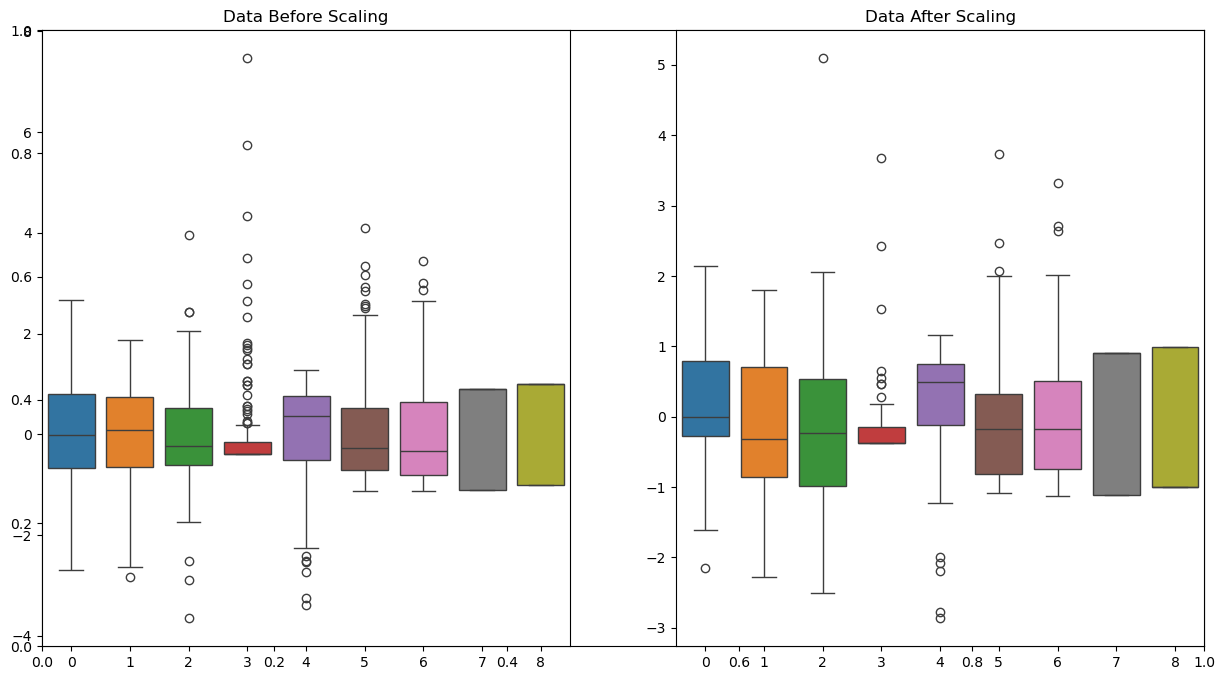

In [269]:
plt.subplots(figsize=(15,8))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title('Data Before Scaling')
plt.subplot(1,2,2)
sns.boxplot(data=X_test_scaled)
plt.title('Data After Scaling')

## Linear Regression Model

In [278]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
regression=LinearRegression()
regression.fit(X_train_scaled,y_train)
y_pred=regression.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print(f'Mean Absolute Error: {mae},R2-Score: {r2}')

Mean Absolute Error: 0.607566966552635,R2-Score: 0.9888523587097926


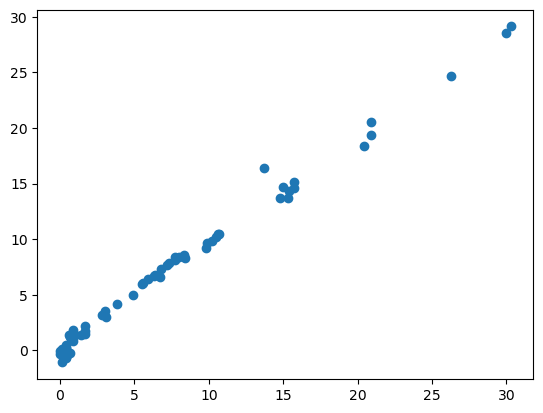

In [273]:
plt.scatter(y_test,y_pred)

## Lasso Regression

Mean Absolute Error: 1.2227720614689965,R2-Score: 0.9498780896144685


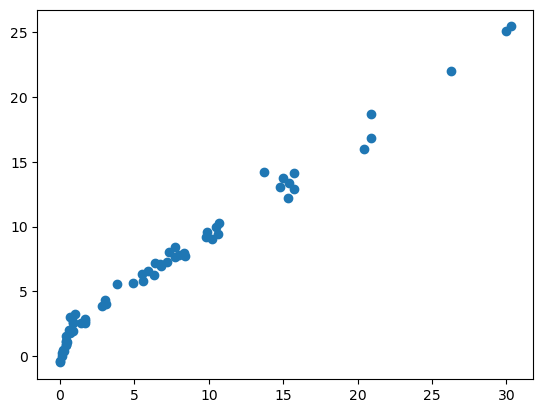

In [277]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, r2_score
lasso=Lasso()
lasso.fit(X_train_scaled,y_train)
y_pred=lasso.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print(f'Mean Absolute Error: {mae},R2-Score: {r2}')
plt.scatter(y_test,y_pred)

## Ridge Regression

Mean Absolute Error: 0.6309880485441118,R2-Score: 0.98815903969299


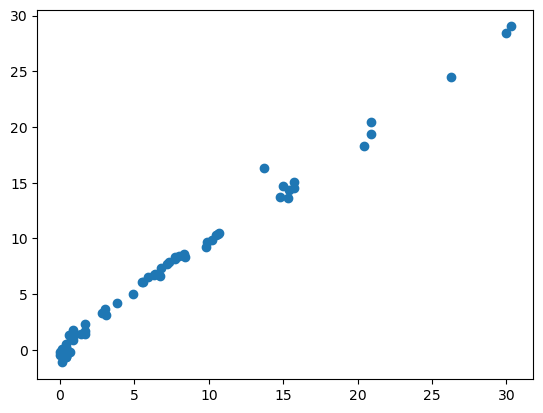

In [279]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
ridge=Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred=ridge.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print(f'Mean Absolute Error: {mae},R2-Score: {r2}')
plt.scatter(y_test,y_pred)

## ElasticNet

Mean Absolute Error: 1.9197940304923342,R2-Score: 0.8748824241780011


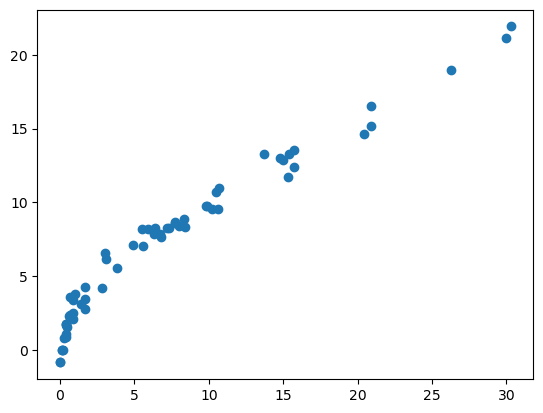

In [280]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, r2_score
en=ElasticNet()
en.fit(X_train_scaled,y_train)
y_pred=en.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print(f'Mean Absolute Error: {mae},R2-Score: {r2}')
plt.scatter(y_test,y_pred)

## Hyperparameter Tuning

#### Lasso CV (Cross-Validation)

In [282]:
from sklearn.linear_model import LassoCV
lasso_CV = LassoCV(cv=5)

In [283]:
lasso_CV.fit(X_train_scaled,y_train)

,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,copy_X,True
,cv,5
,verbose,False
,n_jobs,None


In [284]:
lasso_CV.alpha_

np.float64(0.026808871166009655)

In [287]:
y_pred=lasso_CV.predict(X_test_scaled)

Mean Absolute Error: 0.6456669987880042 & R2-Score: 0.9879350695757396


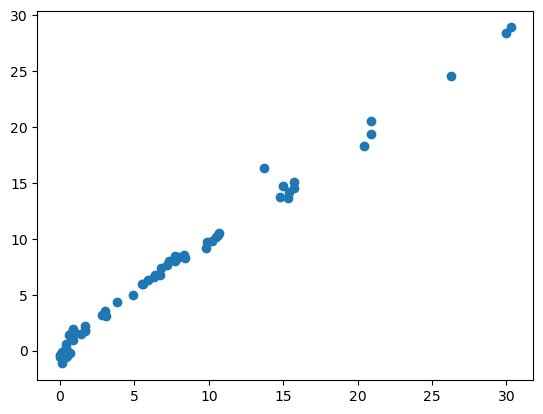

In [290]:
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print(f'Mean Absolute Error: {mae} & R2-Score: {score}')
plt.scatter(y_test,y_pred)

In [311]:
import pickle
pickle.dump(lasso_CV,open('models/lasso_cv_model.pkl','wb'))

## Ridge CV

In [293]:
from sklearn.linear_model import RidgeCV
ridge_cv=RidgeCV(cv=5)

Mean Absolute Error: 0.6309880485441118 & R2-Score: 0.98815903969299


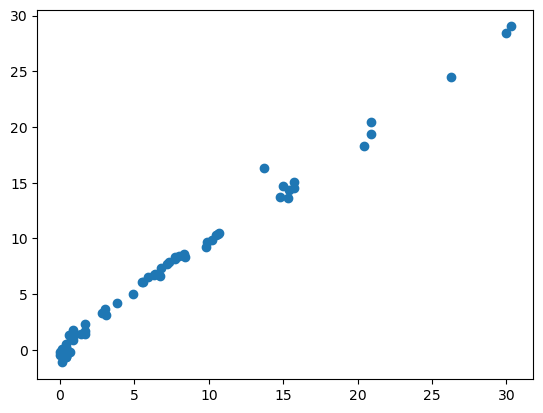

In [328]:
ridge_cv.fit(X_train_scaled,y_train)
y_pred=ridge_cv.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print(f'Mean Absolute Error: {mae} & R2-Score: {score}')
plt.scatter(y_test,y_pred)


In [330]:
test_input = pd.DataFrame([[40, 20, 40, 0, 65.7, 5, 2, 0, 1]], columns=X_train.columns)
test_scaled = scaler.transform(test_input)
print(ridge_cv.predict(test_scaled))

[-16.03202358]


d:\Data BootCamp\Python\venv\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


### Pickle File

In [310]:
import pickle
pickle.dump(ridge_cv,open('models/ridge_cv_model.pkl','wb'))

In [319]:
X_train_scaled.columns

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

### ElasticNet CV

In [299]:
from sklearn.linear_model import ElasticNetCV
en_cv=ElasticNetCV(cv=5)

Mean Absolute Error: 0.664520151238972 & R2-Score: 0.9872741775099948


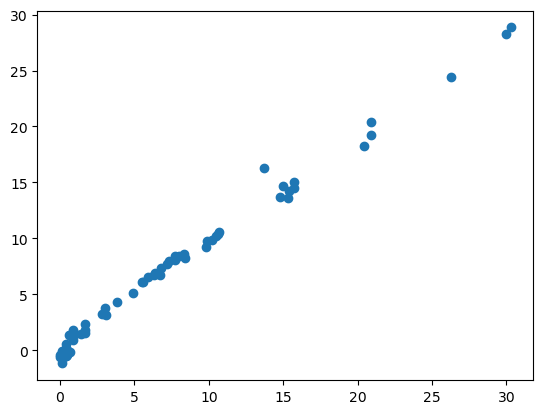

In [300]:
en_cv.fit(X_train_scaled,y_train)
y_pred=en_cv.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print(f'Mean Absolute Error: {mae} & R2-Score: {score}')
plt.scatter(y_test,y_pred)


In [301]:
en_cv.alpha_

np.float64(0.018826217368346294)

In [307]:
en_cv.alphas_

array([13.28152418, 12.3863939 , 11.55159241, 10.77305374, 10.04698598,
        9.36985275,  8.73835603,  8.14942008,  7.60017644,  7.08794999,
        6.61024588,  6.16473743,  5.74925476,  5.36177423,  5.0004086 ,
        4.66339779,  4.34910039,  4.05598558,  3.78262572,  3.52768941,
        3.28993495,  3.06820435,  2.86141764,  2.66856767,  2.48871514,
        2.32098407,  2.16455751,  2.01867358,  1.88262174,  1.75573933,
        1.63740838,  1.52705253,  1.4241343 ,  1.32815242,  1.23863939,
        1.15515924,  1.07730537,  1.0046986 ,  0.93698527,  0.8738356 ,
        0.81494201,  0.76001764,  0.708795  ,  0.66102459,  0.61647374,
        0.57492548,  0.53617742,  0.50004086,  0.46633978,  0.43491004,
        0.40559856,  0.37826257,  0.35276894,  0.3289935 ,  0.30682043,
        0.28614176,  0.26685677,  0.24887151,  0.23209841,  0.21645575,
        0.20186736,  0.18826217,  0.17557393,  0.16374084,  0.15270525,
        0.14241343,  0.13281524,  0.12386394,  0.11551592,  0.10

In [309]:
import pickle 
pickle.dump(en_cv,open('models/ElasticNet_Model.pkl','wb'))


In [312]:
pickle.dump(scaler,open('models/scaler.pkl','wb'))

In [331]:
df[df['Classes'] == 1].sample(3)

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
11,26.0,81.0,19.0,0.0,84.0,13.8,61.4,4.8,17.7,7.1,1,0
128,35.0,44.0,17.0,0.2,85.6,9.9,28.9,5.4,10.7,6.0,1,1
67,32.0,69.0,16.0,0.0,86.5,15.5,48.6,5.5,17.2,8.0,1,0
